# Homework 1: Score Matching and Langevin Dynamics

In this section, we will implement Langevin Dynamics on a simple 2D Mixture of Gaussians Model.

It is prohibited to use the library ```torch.distributions``` throughout this homework, as well as any other libraries that do similar calculations such as ```scipy.stats```.

Note that GPUs will not help in any part except the final section with the generation of images (everything else runs in less than a second), so it is recommended to run this part of the homework on a local CPU.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.init as init
import numpy as np
import random                
import matplotlib.pyplot as plt

## Part 1: Computing the density and score of a Gaussian Mixture Model

A Gaussian Mixture Model is a distribution that is the combination of several Gaussian distributions, such as the following:

$$
X | Y \sim \mathcal{N}(\mu_1, \sigma_1 I)Y + \mathcal{N}(\mu_2, \sigma_2 I)(1 - Y)
$$

where $Y \sim \text{Ber}(p)$. In our case, $X \in \mathbb{R}^2$.

Implement the following functions to compute the density and score of a GMM. You can add any other functions required. For score computation, do not use torch's autograd (it will greatly hinder the performance).

In [2]:
mu_1 = torch.tensor([1., 1.])
mu_2 = torch.tensor([-1., -1.])

sigma_1 = torch.sqrt(torch.tensor(0.1))
sigma_2 = torch.sqrt(torch.tensor(0.1))

p_first = torch.tensor(0.15)  # The probability that I will sample from the first distribution.

**Calculation of the density**

Let's use the law of total probability:
\begin{align*}
f_X(X=\mathbf{x})&=\sum_{y}{f_{X|Y}{(X|Y=y)} \cdot P(Y=y)} \\
        &=f_{X|Y}{(X|Y=0)} \cdot |P(Y=0) + f_{X|Y}{(X|Y=1)} \cdot P(Y=1) \\
\end{align*}

The density of a GMM conditioned on a pecific value of the Bernouli r.v will be just the multivariate Normal density:
$$
Z \sim \mathcal{N}(\mu, \sigma I) \implies f_Z(Z=\mathbf{z})=\frac{1}{2\pi \sigma^2} \exp\!\Bigl(-\tfrac{1}{2\sigma^2} \|\mathbf{z} - \boldsymbol{\mu}\|^2\Bigr).
$$

To conclude we have:
$$
f_X(X=\mathbf{x})=p \cdot \frac{1}{2\pi \sigma_{1}^2} \exp\!\Bigl(-\tfrac{1}{2\sigma_{1}^2} \|\mathbf{x} - \boldsymbol{\mu_1}\|^2\Bigr) + (1-p) \cdot \frac{1}{2\pi \sigma_{2}^2} \exp\!\Bigl(-\tfrac{1}{2\sigma_{2}^2} \|\mathbf{x} - \boldsymbol{\mu_2}\|^2\Bigr)
$$

In [3]:
def normal_density(X, mu, sigma):
    return (1 / (2 * torch.pi * (sigma ** 2))) * (torch.e ** (-((torch.linalg.vector_norm(X - mu.unsqueeze(0), dim=1)) ** 2) / (2 * (sigma ** 2)))) 

def density_gmm(X, mu_1, mu_2, sigma_1, sigma_2, p):
    """
    :param X: input data: tensor of shape (N, 2)
    :param mu_1: mean of the first Gaussian
    :param mu_2: mean of the second Gaussian
    :param sigma_1: standard deviation of the first Gaussian
    :param sigma_2: standard deviation of the second Gaussian
    :param p: probability of the first Gaussian
    :return: density of the Gaussian Mixture Model at point X: tensor of shape (N,)
    """
    
    dens1 = normal_density(X, mu_1, sigma_1)
    dens2 = normal_density(X, mu_2, sigma_2)
    return (p * dens1) + ((1 - p) * dens2)

**Calculation of the score**

Let's find the score expression:

\begin{align*}
&\nabla_{\mathbf{x}} \log{f_X(X=\mathbf{x})} \underset{\text{rules of derivatives}}{=} \frac{\nabla f_X(X=\mathbf{x})}{f_X(X=\mathbf{x})}
\end{align*}

Denote for simplicity the density of each one of the Gaussians by: $f^1_X(\mathbf{x})$ and $f^2_X(\mathbf{x})$. Then further simplifying the expression from above, we get:

\begin{align*}
&\nabla_{\mathbf{x}} \log{f_X(X=\mathbf{x})} = \frac{\nabla_X \Bigl[ \ p \cdot f^1_X(\mathbf{x}) + (1-p) \cdot f^2_X(\mathbf{x}) \Bigr]}{\ p \cdot f^1_X(\mathbf{x}) + (1-p) \cdot f^2_X(\mathbf{x})} = \frac{p \cdot \nabla_X f^1_X(\mathbf{x}) + (1-p) \cdot \nabla_X f^2_X(\mathbf{x})}{\ p \cdot f^1_X(\mathbf{x}) + (1-p) \cdot f^2_X(\mathbf{x})}
\end{align*}

Now, notice that because of the derivation rules of $e^{f(x)}$, it holds: $$\nabla_X{f^{i}_X} = -\frac{\mathbf{x}-\mu_i}{\sigma_i^2} \cdot f^i_X$$ Thus, to conclude:

$$
\nabla_{\mathbf{x}} \log f_{X}(\mathbf{x})
\;=\;
-\,\frac{
  p \,\frac{\mathbf{x} - \mu_1}{\sigma_1^2}\;f^{1}_X(\mathbf{x})
  +
  (1 - p)\,\frac{\mathbf{x} - \mu_2}{\sigma_2^2}\;f^{2}_X(\mathbf{x})
}{
  f_X(\mathbf{x})
}
$$

In [4]:
def score_gmm(X, mu_1, mu_2, sigma_1, sigma_2, p):
    """
    :param X: input data: tensor of shape (N, 2)
    :param mu_1: mean of the first Gaussian: tensor of shape (2,)
    :param mu_2: mean of the second Gaussian: tensor of shape (2,)
    :param sigma_1: standard deviation of the first Gaussian: tensor of shape (1,)
    :param sigma_2: standard deviation of the second Gaussian: tensor of shape (1,)
    :return: score of the Gaussian Mixture Model at point X: tensor of shape (N, 2, 2)
    """
    term1 = p * ((X - mu_1) / (sigma_1 ** 2)) * (normal_density(X, mu_1, sigma_1).unsqueeze(1))
    term2 = (1 - p) * ((X - mu_2) / (sigma_2 ** 2)) * (normal_density(X, mu_2, sigma_2).unsqueeze(1))
    divider = density_gmm(X, mu_1, mu_2, sigma_1, sigma_2, p).unsqueeze(1)

    return  -((term1 + term2) / (divider))

### Visualization

Using a heatmap (with plt.imshow) and an arrow plot (plt.quiver), generate a plot of the density function and score.

/home/zakhar/.local/miniconda3/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


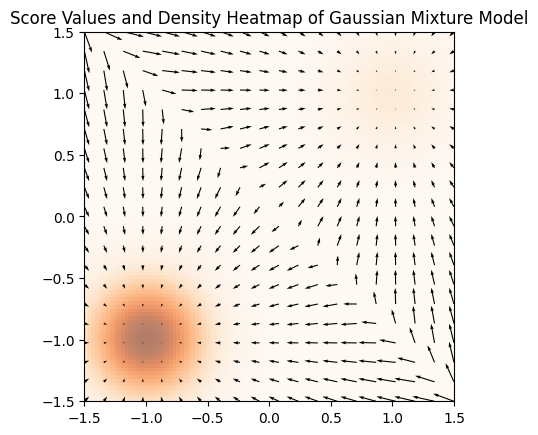

In [5]:
# Steps:
# 1. Create a grid from -1.5 to 1.5 in both dimensions, with 100 points in each dimension (using torch.linspace and torch.meshgrid)
# 2. Compute the density of the Gaussian Mixture Model at each point on the grid and store it in a tensor of shape (100, 100)
# 3. For the quiver plot, create a grid from -1.5 to 1.5 in both dimensions, with 20 points in each dimension
# 4. Compute the score of the Gaussian Mixture Model at each point on the grid and store it in a tensor of shape (20, 20, 2)
# 5. Create a quiver plot with the grid points as the X and Y coordinates and the score as the U and V components
# 6. Create a heatmap of the density, with the grid points as the X and Y coordinates and the density as the color, becoming darker as the density is larger

DENSITY_GRID_SIZE = 100
SCORE_GRID_SIZE = 20

# fig = plt.figure(figsize=(10,10))
# ax = fig.add_subplot(111, projection='3d')

density_grid = torch.zeros(DENSITY_GRID_SIZE, DENSITY_GRID_SIZE)  # Replace this with the relevant matrix, using torch.linspace and torch.meshgrid
score_grid = torch.zeros(SCORE_GRID_SIZE, SCORE_GRID_SIZE, 2)  # Replace this with the relevant matrix, using torch.linspace and torch.meshgrid
density_values = torch.zeros(DENSITY_GRID_SIZE, DENSITY_GRID_SIZE)  # Fill this with the density values
score_values = torch.zeros(SCORE_GRID_SIZE, SCORE_GRID_SIZE, 2)  # Fill this with the score values

#### ADD YOUR CODE HERE ####

# defining x,y linspaces and grid for the densities
x = torch.linspace(-1.5, 1.5, steps=DENSITY_GRID_SIZE)
y = torch.linspace(-1.5, 1.5, steps=DENSITY_GRID_SIZE)

# reshaping the grid to (N,2)
density_grid = torch.meshgrid(x, y)
grid_x = density_grid[0].reshape(-1)
grid_y = density_grid[1].reshape(-1)
points = torch.stack([grid_x, grid_y], dim=1)
density_values = density_gmm(points, mu_1, mu_2, sigma_1, sigma_2, p_first)   # calculate density
density_values = density_values.reshape(DENSITY_GRID_SIZE, DENSITY_GRID_SIZE)  # reshape into image dimension (grid_size, grid_size)

# defining x,y linspaces and grid for the scores
x = torch.linspace(-1.5, 1.5, steps=SCORE_GRID_SIZE)
y = torch.linspace(-1.5, 1.5, steps=SCORE_GRID_SIZE)
score_grid = torch.meshgrid(x, y)

# same procedure - reshaping the grid and calculating score
score_grid_x = score_grid[0].reshape(-1)
score_grid_y = score_grid[1].reshape(-1)
score_points = torch.stack([score_grid_x, score_grid_y], dim=1)
score_values = score_gmm(score_points, mu_1, mu_2,sigma_1, sigma_2, p_first)
score_values = score_values.reshape(SCORE_GRID_SIZE, SCORE_GRID_SIZE, 2)

# fitting the grid to be of shape (SCORE_GRID_SIZE, SCORE_GRID_SIZE, 2)
new_grid = torch.zeros(SCORE_GRID_SIZE, SCORE_GRID_SIZE, 2)
for i, axis in enumerate(score_grid):
    new_grid[:, :, i] = axis
score_grid = new_grid


#### DONE WITH SOLUTION ####

plt.imshow(density_values, extent=(-1.5, 1.5, -1.5, 1.5), origin='lower', cmap='Oranges', alpha=0.6)
plt.quiver(score_grid[:, :, 0], score_grid[:, :, 1], score_values[:, :, 0], score_values[:, :, 1], color='black')
plt.title('Score Values and Density Heatmap of Gaussian Mixture Model')
plt.show()

Example output on standard Gaussian:

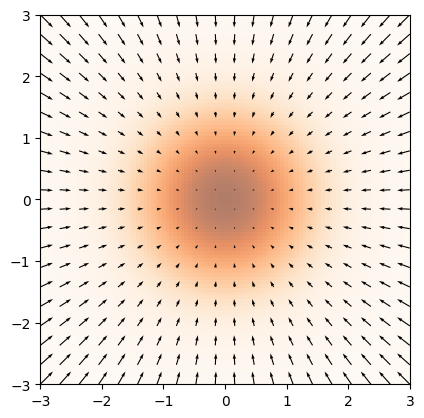

## Part 2: Training a score network

Implement a model that is able to compute the score of a given point sampled from the GMM.

In [6]:
class ScoreMatcher(nn.Module):
    def __init__(self, input_size=2, hidden_size=128, output_size=2):
        super(ScoreMatcher, self).__init__()
        self.sequence = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Softplus(),
            nn.Linear(hidden_size, hidden_size),
            nn.Softplus(),
            nn.Linear(hidden_size, output_size)
        )
        
    def forward(self, x):
        out = self.sequence(x)
        return out


Our samples are small in size compared to real scenario data examples (images), there fore we will pass the entire training set to the model in each epoch.

In [7]:
def gmm_sample(sample_size, mu_1, mu_2, sigma_1, sigma_2, p):
    # sample from Bernoulli
    probs = torch.tensor([p]*sample_size)
    Y = torch.bernoulli(probs)
    
    # sample from Normal
    means_1 = mu_1.unsqueeze(dim=0).repeat(sample_size, 1)
    means_2 = mu_2.unsqueeze(dim=0).repeat(sample_size, 1)
    sample_1 = torch.normal(means_1, sigma_1)
    sample_2 = torch.normal(means_2, sigma_2)
    
    # mask according to the boolean values
    sample_1[~(Y.bool())]=0
    sample_2[Y.bool()]=0
    
    X = sample_1 + sample_2
    return X

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def train(mu_1, mu_2, sigma_1, sigma_2, p, train_size, num_epochs, lr):
    """ Return a trained ScoreMatcher model """
    model = ScoreMatcher().to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr)
    X_train = torch.zeros((train_size, *mu_1.shape))
    score_train = torch.zeros((train_size, *mu_1.shape))
    
    # creating training set by sampling from the GMM
    X_train = gmm_sample(train_size, mu_1, mu_2, sigma_1, sigma_2, p)
    score_train = score_gmm(X_train, mu_1, mu_2, sigma_1, sigma_2, p).to(device)
    X_train = X_train.to(device)

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, score_train)
        loss.backward()
        optimizer.step()

        if ((epoch+1) % 50 == 0):
            print(f"Epoch {epoch+1}. Loss: {loss}")
        if loss < 0.01:
            break
    X_train = X_train.detach().to('cpu')
    score_train = score_train.detach().to('cpu')
    return model

Print the loss value at each epoch. Make sure the loss is lower than 0.01

In [8]:
model = train(mu_1, mu_2, sigma_1, sigma_2, p_first, 1000, 1000, 0.01)

Epoch 50. Loss: 1.9770621061325073
Epoch 100. Loss: 0.949038028717041
Epoch 150. Loss: 0.7300325036048889
Epoch 200. Loss: 0.2519952654838562
Epoch 250. Loss: 0.23144078254699707
Epoch 300. Loss: 0.03483254089951515
Epoch 350. Loss: 0.1899261325597763
Epoch 400. Loss: 0.019904905930161476
Epoch 450. Loss: 0.09517156332731247
Epoch 500. Loss: 0.012701044790446758
Epoch 550. Loss: 0.14241012930870056


Create a similar visualization to the visualization you created with the true score, replacing the true score with the model.

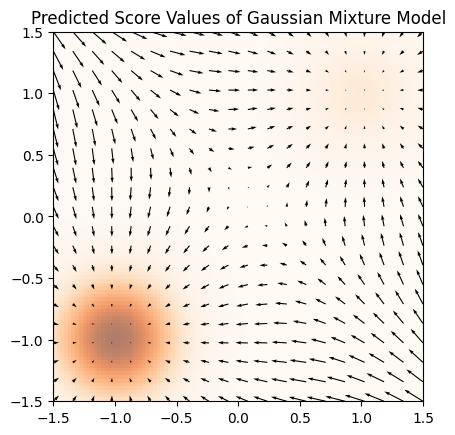

In [9]:
density_grid = torch.zeros(DENSITY_GRID_SIZE, DENSITY_GRID_SIZE) 
score_grid = torch.zeros(SCORE_GRID_SIZE, SCORE_GRID_SIZE, 2) 
density_values = torch.zeros(DENSITY_GRID_SIZE, DENSITY_GRID_SIZE)
score_values = torch.zeros(SCORE_GRID_SIZE, SCORE_GRID_SIZE, 2)

#### ADD YOUR CODE HERE ####

# defining x,y linspaces and grid for the densities
x = torch.linspace(-1.5, 1.5, steps=DENSITY_GRID_SIZE)
y = torch.linspace(-1.5, 1.5, steps=DENSITY_GRID_SIZE)

# reshaping the grid to (N,2)
density_grid = torch.meshgrid(x, y)
grid_x = density_grid[0].reshape(-1)
grid_y = density_grid[1].reshape(-1)
points = torch.stack([grid_x, grid_y], dim=1)
density_values = density_gmm(points, mu_1, mu_2, sigma_1, sigma_2, p_first)   # calculate density
density_values = density_values.reshape(DENSITY_GRID_SIZE, DENSITY_GRID_SIZE)  # reshape into image dimension (grid_size, grid_size)

# defining x,y linspaces and grid for the scores
x = torch.linspace(-1.5, 1.5, steps=SCORE_GRID_SIZE)
y = torch.linspace(-1.5, 1.5, steps=SCORE_GRID_SIZE)
score_grid = torch.meshgrid(x, y)

# same procedure - reshaping the grid and calculating score
score_grid_x = score_grid[0].reshape(-1)
score_grid_y = score_grid[1].reshape(-1)
score_points = torch.stack([score_grid_x, score_grid_y], dim=1)
with torch.no_grad():
    score_values = model(score_points.to(device)).to('cpu')
score_values = score_values.reshape(SCORE_GRID_SIZE, SCORE_GRID_SIZE, 2)

# fitting the grid to be of shape (SCORE_GRID_SIZE, SCORE_GRID_SIZE, 2)
new_grid = torch.zeros(SCORE_GRID_SIZE, SCORE_GRID_SIZE, 2)
for i, axis in enumerate(score_grid):
    new_grid[:, :, i] = axis
score_grid = new_grid

#### DONE WITH SOLUTION ####

plt.imshow(density_values, extent=(-1.5, 1.5, -1.5, 1.5), origin='lower', cmap='Oranges', alpha=0.6)
plt.quiver(score_grid[:, :, 0], score_grid[:, :, 1], score_values[:, :, 0], score_values[:, :, 1], color='black')
plt.title('Predicted Score Values of Gaussian Mixture Model')
plt.show()

Compare the visualizations and explain what could be causing the differences.

We see that overall, the prediction of the scores is not so bad. The significant difference between the original plot and the plot above is that for the points that have a low density (mainly points in the top-left corner and the points in the bottom-right corner), are not very consistent with the true scores.

This makes sense because if we sample $\{ x_i \}_{i=1}^n \sim p_{data}^n$, then for the region where the density is approximately zero denoted by $\mathscr{R} \subset \mathbb{R}^d$ ($\forall x \in \mathscr{R}: p_{data}(x) \approx 0$), then $\{ x_i \}_{i=1}^n \cap \mathscr{R} = \emptyset$. Therefore, the model does not have enough data to estimate the true score in those regions.

## Part 3: Sampling

In this section we will sample from our distribution using several methods:
1. Directly sampling using torch functions
2. Using Langevin Dynamics using the model that we trained.
3. Using Annealed Langevin Dynamics using the true score function.

Sample 1000 points from the GMM and display them using a scatterplot.

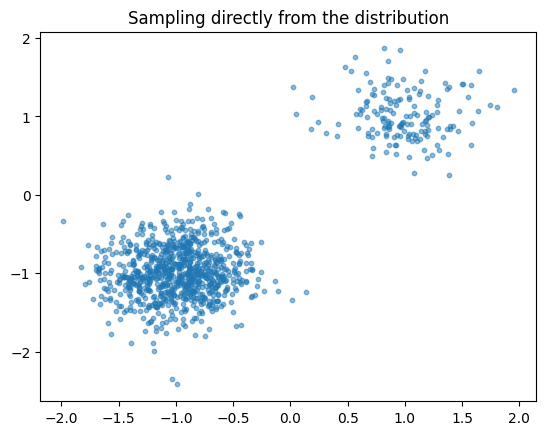

In [10]:
N = 1000

# YOUR CODE HERE
X_sample = gmm_sample(N, mu_1, mu_2, sigma_1, sigma_2, p_first)
plt.scatter(X_sample[:, 0], X_sample[:, 1], marker='o', s=10, alpha=0.5)
plt.title('Sampling directly from the distribution')
plt.show()

Sample 1000 points using the score model (Langevin Dynamics).

100%|██████████| 10000/10000 [00:03<00:00, 2665.74it/s]


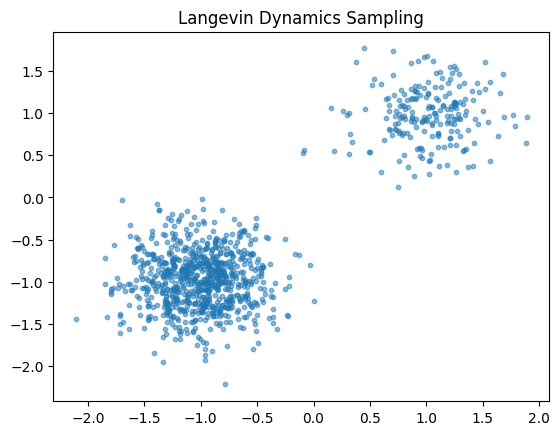

In [11]:
LANGEVIN_STEP_SIZE = 0.01
LANGEVIN_NUM_STEPS = 10000

### YOUR CODE HERE ###
from tqdm import trange
X_langevin_sample = torch.randn((N,2)).to(device)
with torch.no_grad():
    for step in trange(LANGEVIN_NUM_STEPS):
        # sampling noise
        noise = torch.randn((N,2))
        # moving towards the aproximated score + noise
        X_langevin_sample_no_noise = X_langevin_sample + ((LANGEVIN_STEP_SIZE/2) * model(X_langevin_sample))
        X_langevin_sample =  X_langevin_sample_no_noise.to('cpu') + (np.sqrt(LANGEVIN_STEP_SIZE) * noise)
        X_langevin_sample = X_langevin_sample.to(device)
    X_langevin_sample = X_langevin_sample.to('cpu')
    
plt.scatter(X_langevin_sample[:, 0], X_langevin_sample[:, 1], marker='o', s=10, alpha=0.5)
plt.title('Langevin Dynamics Sampling')
plt.show()


We see that both separated regions consist approximately the same amount of samples after the Langevin Dynamics process, even though one region is "supposed to be" more dense than the other

Sample 1000 points using Annealed Langevin Dynamics and the true score function. Show the sample after applying each noise scale.
Remember that as the noise is smaller, we want to decrease the step size of Langevin Dynamics, so remember to update the step size according to the following formula:

$$\eta_t = \eta_\text{original} \cdot \frac{\sigma_t^2}{\sigma_T^2}$$

Because we are using normal distributions, the noised distributions $p_\sigma$ will just have more variance.

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1760103/3451553142.py:19: SyntaxWarning: invalid escape sequence '\s'
  ax[i // 5, i % 5].set_title(f'$ \sigma = {sigma_i} $')


The noise being added to the data at each step is: tensor([2.0000, 1.1101, 0.6162, 0.3420, 0.1898, 0.1054, 0.0585, 0.0325, 0.0180,
        0.0100]) (geometric sequence)


100%|██████████| 10000/10000 [00:07<00:00, 1398.25it/s]


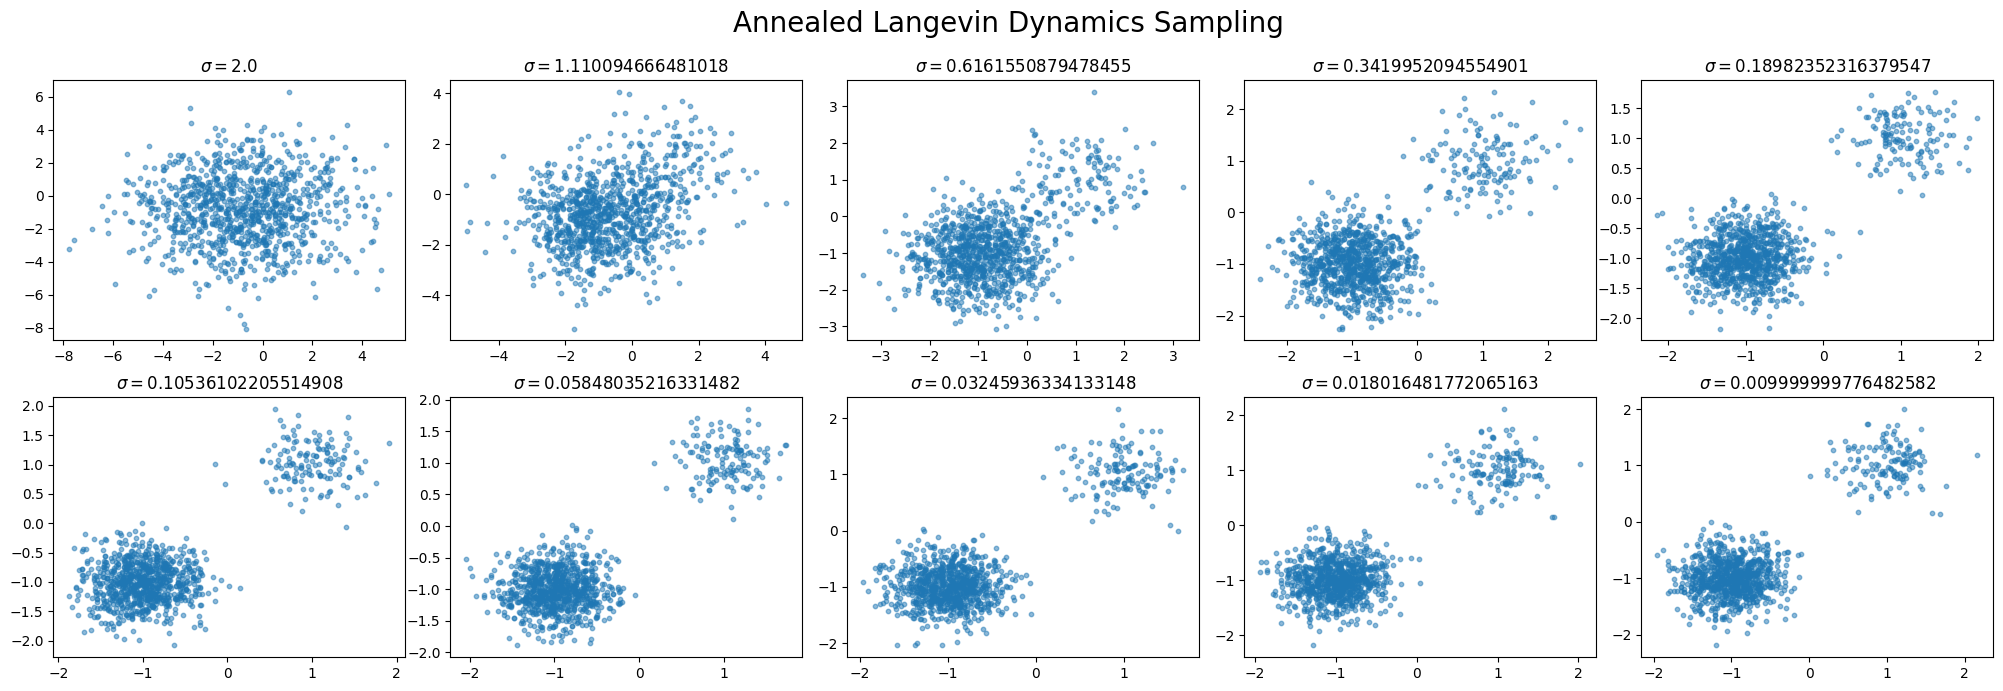

In [12]:
NOISE_SCALES = torch.logspace(torch.log10(torch.tensor(2.0)), torch.log10(torch.tensor(0.01)), 10)
LANGEVIN_STEP_SIZE = 1e-6
print(f'The noise being added to the data at each step is: {NOISE_SCALES} (geometric sequence)')

### YOUR CODE HERE ###
X_annealed_langevin_sample = torch.randn((N,2))

fig, ax = plt.subplots(2, int(len(NOISE_SCALES)/2), figsize=(20,7), height_ratios=[1, 1])

for i, sigma_i in enumerate(NOISE_SCALES):
    lr = LANGEVIN_STEP_SIZE * ((sigma_i ** 2) / (NOISE_SCALES[-1] ** 2))
    for step in trange(LANGEVIN_NUM_STEPS):
        # sampling noise
        noise = torch.randn((N,2))
        score = score_gmm(X_annealed_langevin_sample, mu_1, mu_2, torch.sqrt((sigma_1 ** 2) + (sigma_i ** 2)), torch.sqrt((sigma_2 ** 2) + (sigma_i ** 2)), p_first)
        # moving towards the real score + noise
        X_annealed_langevin_sample = X_annealed_langevin_sample + ((lr / 2) * score) + (torch.sqrt(lr) * noise)
    ax[i // 5, i % 5].scatter(X_annealed_langevin_sample[:, 0], X_annealed_langevin_sample[:, 1], marker='o', s=10, alpha=0.5)
    ax[i // 5, i % 5].set_title(f'$ \sigma = {sigma_i} $')
plt.tight_layout()
fig.suptitle('Annealed Langevin Dynamics Sampling', fontsize=20)
fig.subplots_adjust(top=0.88)
plt.show()


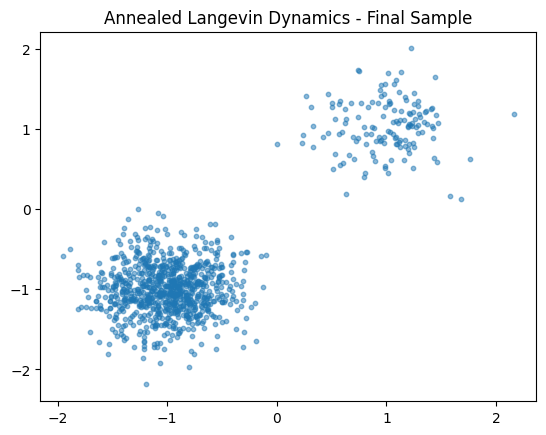

In [13]:
# plotting the final plot
plt.scatter(X_annealed_langevin_sample[:, 0], X_annealed_langevin_sample[:, 1], marker='o', s=10, alpha=0.5)
plt.title('Annealed Langevin Dynamics - Final Sample')
plt.show()

## Putting it all together!

In this section you will be using everything you learned to generate images from MNIST, provided to you in your virtual machines (and available in Pytorch). Ideas are based on the paper Generative Modeling by Estimating Gradients of the Data Distribution (2019). You can use the paper's official implementation as a guideline to the solution. It is recommended to go over the first tutorial before solving.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 1 - Denoising Score Matching

When the score function cannot be calculated directly (as above), we cannot simply use the MSE between the model output and the true score. Hence, we updated loss function, suiting it to our annealed noise schedule:

$$\ell_\text{denoise}(\theta; \sigma) := \frac{1}{2}\mathbb{E}_{x\sim p_\text{data}} \mathbb{E}_{\tilde{x}\sim q_\sigma(\cdot | x)} \left[ \Vert s_\theta(\tilde{x}, \sigma) - \log q_\sigma(\tilde{x}|x)\Vert^2 \right]$$
$$  L_\text{denoise}(\theta) = \frac{1}{L}\sum_{i=1}^L \lambda(\sigma_i)\ell_\text{denoise}(\theta; \sigma_i) \equiv \mathbb{E}_{i \sim \text{Uni}(1, L)} \left[ \sigma_i^2\ell_\text{denoise}(\theta; \sigma_i) \right] $$

Where the model is denoted as $s_\theta$ and $\sigma_i$ are the noise values.

In [54]:
def denoising_score_loss(model, x, noise_scales):
    """
    model: The score matching model.
    x: The input data [BATCH_SIZE, WIDTH, HEIGHT]
    noise_scales: The noise scales to use for denoising [NUM_NOISE_SCALES] (sigma_1, sigma_2, ..., sigma_L)
    """

    ### YOUR CODE HERE ###
    noise_scale_idx = torch.randint(0, len(noise_scales), (x.shape[0],), device=device)  # Random noise scale for each sample in the batch
    noise_scale_batch = noise_scales[noise_scale_idx].view(-1, 1, 1, 1) 

    noise = torch.randn_like(x)
    x_perturbed = x + (noise_scale_batch * noise)
    # x_perturbed.clamp_(0 ,1)
    target = -1 / (noise_scale_batch**2) * (x_perturbed - x)
    out = model(x_perturbed, noise_scale_idx)
    out = out.view(out.shape[0], -1)
    target = target.view(target.shape[0], -1)
    loss = 1 / 2. * ((out - target)**2).sum(dim=-1) * noise_scale_batch.squeeze() ** 2
    return loss.mean(dim=0)

### 2 - UNet

A great candidate for a model that receives an image and returns a value that is of the same dimensions as the image is a UNet. Below is a UNet architecture already implemented for you. In this section you don't need to implement / change anything, if you do please specify your changes below.

In [55]:
class CondInstanceNorm(nn.Module):
    def __init__(self, in_channels, n_noise_scale=10, eps=1e-5):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(n_noise_scale, in_channels))
        self.beta = nn.Parameter(torch.zeros(n_noise_scale, in_channels))
        self.alpha = nn.Parameter(torch.zeros(n_noise_scale, in_channels))
        self.eps = eps

    def forward(self, x, noise_scale_idx):
        bsz = x.shape[0]
        gamma = self.gamma[noise_scale_idx].view(bsz, -1, 1, 1)  # (bsz, in_channels, 1, 1)
        beta = self.beta[noise_scale_idx].view(bsz, -1, 1, 1)
        alpha = self.alpha[noise_scale_idx].view(bsz, -1, 1, 1)


        mu = x.mean(dim=(2, 3), keepdim=True)  # (batch_size, in_channels, 1, 1)
        var = x.var(dim=(2, 3), keepdim=True)  # (batch_size, in_channels, 1, 1)
        sigma = torch.sqrt(var + self.eps)  # (batch_size, in_channels, 1, 1)
        

        x = (x - mu) / sigma  # (batch_size, in_channels, height, width)
        x = gamma * x + beta  # (batch_size, in_channels, height, width)

        m = mu.mean(dim=1, keepdim=True)  # (batch_size, 1, 1, 1)
        if mu.shape[1] == 1:
            s = torch.ones_like(mu)
        else:
            v = mu.var(dim=1, keepdim=True)  # (batch_size, 1, 1, 1)
            s = torch.sqrt(v + self.eps)  # (batch_size, 1, 1, 1)

        x = x + alpha * (mu - m) / s  # (batch_size, in_channels, height, width)
        return x


class ResidualConvUnit(nn.Module):
    def __init__(self, channels, norm=True, kernel_size=3, n_noise_scale=10):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding='same')
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding='same')
        self.norm1 = CondInstanceNorm(channels, n_noise_scale) if norm else None
        self.norm2 = CondInstanceNorm(channels, n_noise_scale) if norm else None
        self.act = nn.ELU()

    def forward(self, x, noise_scale_idx):
        # x: (batch_size, in_channels, height, width)
        h = self.norm1(x, noise_scale_idx) if self.norm1 is not None else x
        h = self.act(h)
        h = self.conv1(h)

        h = self.norm2(h, noise_scale_idx) if self.norm2 is not None else h
        h = self.act(h)
        h = self.conv2(h)
        
        return x + h
    
    

class StridedConvUnit(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, n_noise_scale=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size//2, stride=2)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, padding='same')
        self.norm1 = CondInstanceNorm(in_channels, n_noise_scale)
        self.norm2 = CondInstanceNorm(out_channels, n_noise_scale)
        self.act = nn.ELU()
    
    def forward(self, x, noise_scale_idx):
        # x: (batch_size, in_channels, height, width)

        h = self.norm1(x, noise_scale_idx)
        h = self.act(h)
        h = self.conv1(h)

        h = self.norm2(h, noise_scale_idx)
        h = self.act(h)
        h = self.conv2(h)
        
        return h


class DilatedConvUnit(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=2, n_noise_scale=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, dilation=dilation, padding=dilation)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, padding='same')
        self.norm1 = CondInstanceNorm(in_channels, n_noise_scale)
        self.norm2 = CondInstanceNorm(out_channels, n_noise_scale)
        self.act = nn.ELU()

    def forward(self, x, noise_scale_idx):
        # x: (batch_size, in_channels, height, width)

        h = self.norm1(x, noise_scale_idx)
        h = self.act(h)
        h = self.conv1(h)

        h = self.norm2(h, noise_scale_idx)
        h = self.act(h)
        h = self.conv2(h)
        
        return h
    


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, n_layers=2, downsample='stride', dilation=2, n_noise_scale=10):
        assert downsample in ['stride', 'dilation']
        super().__init__()
        self.downsample = downsample
        self.main = nn.ModuleList([])
        for _ in range(n_layers):
            self.main.append(ResidualConvUnit(in_channels, n_noise_scale=n_noise_scale))
        
        if downsample == 'stride':
            self.main.append(StridedConvUnit(in_channels, out_channels, n_noise_scale=n_noise_scale))
        elif downsample == 'dilation':
            self.main.append(DilatedConvUnit(in_channels, out_channels, dilation=dilation, n_noise_scale=n_noise_scale))

    def forward(self, x, noise_scale_idx):
        # x: (batch_size, in_channels, height, width)

        for layer in self.main:
            x = layer(x, noise_scale_idx)
        
        return x
    

class AdaptiveConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, n_noise_scale=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.conv2 = ResidualConvUnit(out_channels, n_noise_scale=n_noise_scale)
        self.conv3 = ResidualConvUnit(out_channels, n_noise_scale=n_noise_scale)

    def forward(self, x, noise_scale_idx):
        # x: (batch_size, in_channels, height, width)

        h = self.conv1(x)
        h = self.conv2(h, noise_scale_idx)
        h = self.conv3(h, noise_scale_idx)
        
        return h
    

class MultiResolutionFusion(nn.Module):
    def __init__(self, channels, n_noise_scale=10):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding='same')
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding='same')
        self.norm1 = CondInstanceNorm(channels, n_noise_scale)
        self.norm2 = CondInstanceNorm(channels, n_noise_scale)

    def forward(self, x, y=None, noise_scale_idx=0):
        if y is None:
            return x
        else:
            h1 = self.norm1(x, noise_scale_idx)
            h1 = self.conv1(h1)

            h2 = self.norm2(y, noise_scale_idx)
            h2 = self.conv2(h2)

            return h1 + h2
        

class ResidualPoolingBlock(nn.Module):
    def __init__(self, channels, n_noise_scale=10):
        super().__init__()
        self.norm1 = CondInstanceNorm(channels, n_noise_scale)
        self.pool1 = nn.AvgPool2d(kernel_size=5, stride=1, padding=2)
        self.norm2 = CondInstanceNorm(channels, n_noise_scale)
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding='same')

    def forward(self, x, noise_scale_idx):
        h = self.norm1(x, noise_scale_idx)
        h = self.pool1(h)
        h = self.norm2(h, noise_scale_idx)
        h = self.conv1(h)

        return h


class ChainedResidualPool(nn.Module):
    def __init__(self, channels, n_noise_scale=10):
        super().__init__()
        self.act = nn.ELU()
        self.pool1 = ResidualPoolingBlock(channels, n_noise_scale=n_noise_scale)
        self.pool2 = ResidualPoolingBlock(channels, n_noise_scale=n_noise_scale)


    def forward(self, x, noise_scale_idx):
        x = self.act(x)
        h = self.pool1(x, noise_scale_idx)
        x = x + h
        h = self.pool2(h, noise_scale_idx)
        x = x + h

        return x

class RefineNetBlock(nn.Module):
    def __init__(self, x1_in, x2_in, channels, n_noise_scale=10):
        super().__init__()
        self.adap_x1 = AdaptiveConvBlock(x1_in, channels, n_noise_scale=n_noise_scale)
        self.adap_x2 = AdaptiveConvBlock(x2_in, channels, n_noise_scale=n_noise_scale)

        self.fusion = MultiResolutionFusion(channels, n_noise_scale=n_noise_scale)
        self.pool = ChainedResidualPool(channels, n_noise_scale=n_noise_scale)

        self.out = ResidualConvUnit(channels, n_noise_scale=n_noise_scale)

    def forward(self, x1, x2=None, noise_scale_idx=0):
        h1 = self.adap_x1(x1, noise_scale_idx)
        h2 = self.adap_x2(x2, noise_scale_idx) if x2 is not None else None
        h = self.fusion(h1, h2, noise_scale_idx)
        h = self.pool(h, noise_scale_idx)
        h = self.out(h, noise_scale_idx)

        return h


class RefineNet(nn.Module):
    def __init__(self, in_channels, hidden_channels=(128, 256), n_noise_scale=10):
        super().__init__()
        self.res1 = ResidualBlock(in_channels, hidden_channels[0], n_layers=2, downsample='stride')
        self.res2 = ResidualBlock(hidden_channels[0], hidden_channels[1], n_layers=2, downsample='dilation', dilation=2)
        ### YOU CAN ADD MORE RESIDUAL BLOCKS HERE ###
        
        self.refine1 = RefineNetBlock(x1_in=hidden_channels[-1], x2_in=hidden_channels[-1], channels=hidden_channels[-1], n_noise_scale=n_noise_scale)
        self.refine2 = RefineNetBlock(x1_in=hidden_channels[-2], x2_in=hidden_channels[-1], channels=hidden_channels[-2], n_noise_scale=n_noise_scale)
        ### EVERY RESIDUAL BLOCK SHOULD BE FOLLOWED BY A REFINE BLOCK ###

        self.up_norm = CondInstanceNorm(hidden_channels[-2], n_noise_scale)
        self.up_conv = nn.ConvTranspose2d(hidden_channels[-2], hidden_channels[-2], kernel_size=3, stride=2, padding=1, output_padding=1)
        self.out = AdaptiveConvBlock(hidden_channels[-2], in_channels, n_noise_scale=n_noise_scale)


    def forward(self, x, noise_scale_idx):
        h1 = self.res1(x, noise_scale_idx)
        h2 = self.res2(h1, noise_scale_idx)

        h = self.refine1(h2, x2=None, noise_scale_idx=noise_scale_idx)  # As we know, U-Nets accept two inputs (previous layer and skip connection)
        h = self.refine2(h1, h, noise_scale_idx)

        h = self.up_norm(h, noise_scale_idx)
        h = self.up_conv(h)
        h = self.out(h, noise_scale_idx)

        return h
    
def q_sample(x, sigma, noise=None):
    # x: (B, C, H, W)
    # sigma: (B, )
    if noise is None:
        noise = torch.randn_like(x)
    while sigma.dim() < x.dim():
        sigma = sigma.unsqueeze(-1)
    return x + sigma * noise
    


### 3 - Training

Train a UNet according to the loss implemented above on MNIST. It is recommended to save checkpoints - the model's state dict in case of the machine turning off / crashing (the code should not need to run more than an hour anyways). All hyperparameters have been provided to you and should work in the case everything was implemented correctly. However, you are free to change any values for better performance.

In [113]:
N_EPOCHS = 60
BATCH_SIZE = 256
NOISE_SCALES = torch.logspace(torch.log10(torch.tensor(1.0)), torch.log10(torch.tensor(0.01)), 10).to(device)
LR = 1e-3  # Learning rate for the training - not the same as the step size of Langevin Dynamics
NUM_LANGEVIN_STEPS = 100  # Number of steps of Langevin Dynamics for each noise scale.
LANGEVIN_STEP_SIZE = 2e-5  # Base step size in Annealed Langevin Dynamics

In [57]:
# use MNIST as train set
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm

transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, drop_last=True)

/home/zakhar/.local/miniconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [115]:
### YOUR CODE HERE ###
from tqdm import trange

model = RefineNet(in_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_steps = []

# path for checkpoints
checkpoint_path = "checkpoints/baseline/checkpoint_epoch120_baseline.pth"
#continue training from checkpoint
if checkpoint_path is not None:
    chkpnt = torch.load(checkpoint_path)
    model.load_state_dict(chkpnt['model_state_dict'])
    optimizer.load_state_dict(chkpnt['optimizer'])
    model = model.to(device)

for epoch in trange(N_EPOCHS):
    loss_avg = 0
    batch_count = 0
    for x, _ in trainloader:    
        batch_count += 1
        model.train()
        loss = denoising_score_loss(model, x.to(device), NOISE_SCALES)
        loss_avg += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    loss_steps.append(loss_avg.div_(batch_count).item())


    if ((epoch+1) % 5) == 0:
        print(f"Epoch: {epoch+121}. Loss: {loss}")
        # saving both the model and optimizer since we are working with Adam
        torch.save({'model_state_dict': model.state_dict(), 'optimizer':optimizer.state_dict()}, \
                   f"checkpoints/baseline/checkpoint_epoch{epoch+121}_baseline.pth")

/tmp/ipykernel_229585/1978358278.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpnt = torch.load(checkpoint_path)
  7%|▋         | 4/60 [04:45<1:06:43, 71.49s/it]

Epoch: 125. Loss: 33.0079231262207


 15%|█▌        | 9/60 [10:44<1:00:52, 71.62s/it]

Epoch: 130. Loss: 32.59375762939453


 23%|██▎       | 14/60 [16:43<54:57, 71.68s/it] 

...

 90%|█████████ | 54/60 [1:04:33<07:10, 71.71s/it]

Epoch: 175. Loss: 29.895946502685547


 98%|█████████▊| 59/60 [1:10:32<01:11, 71.74s/it]

Epoch: 180. Loss: 30.78242301940918


100%|██████████| 60/60 [1:11:44<00:00, 71.75s/it]


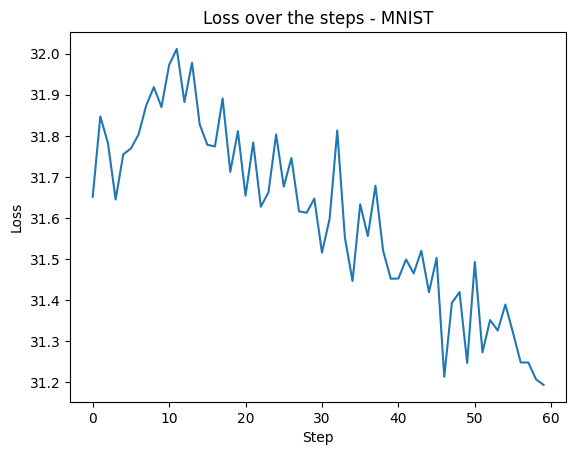

In [116]:
# plotting the loss over the epochs
plt.plot(list(range(len(loss_steps))), loss_steps)
plt.title('Loss over the steps - MNIST')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

### 4 - Sampling

Generate images using Annealed Langevin Dynamics with the model you have trained above. Visualize the process, you can use the function below or any other method. The images do not need to be perfect but it must be clear that they are handwritten digits with a black background. Example imperfect output:

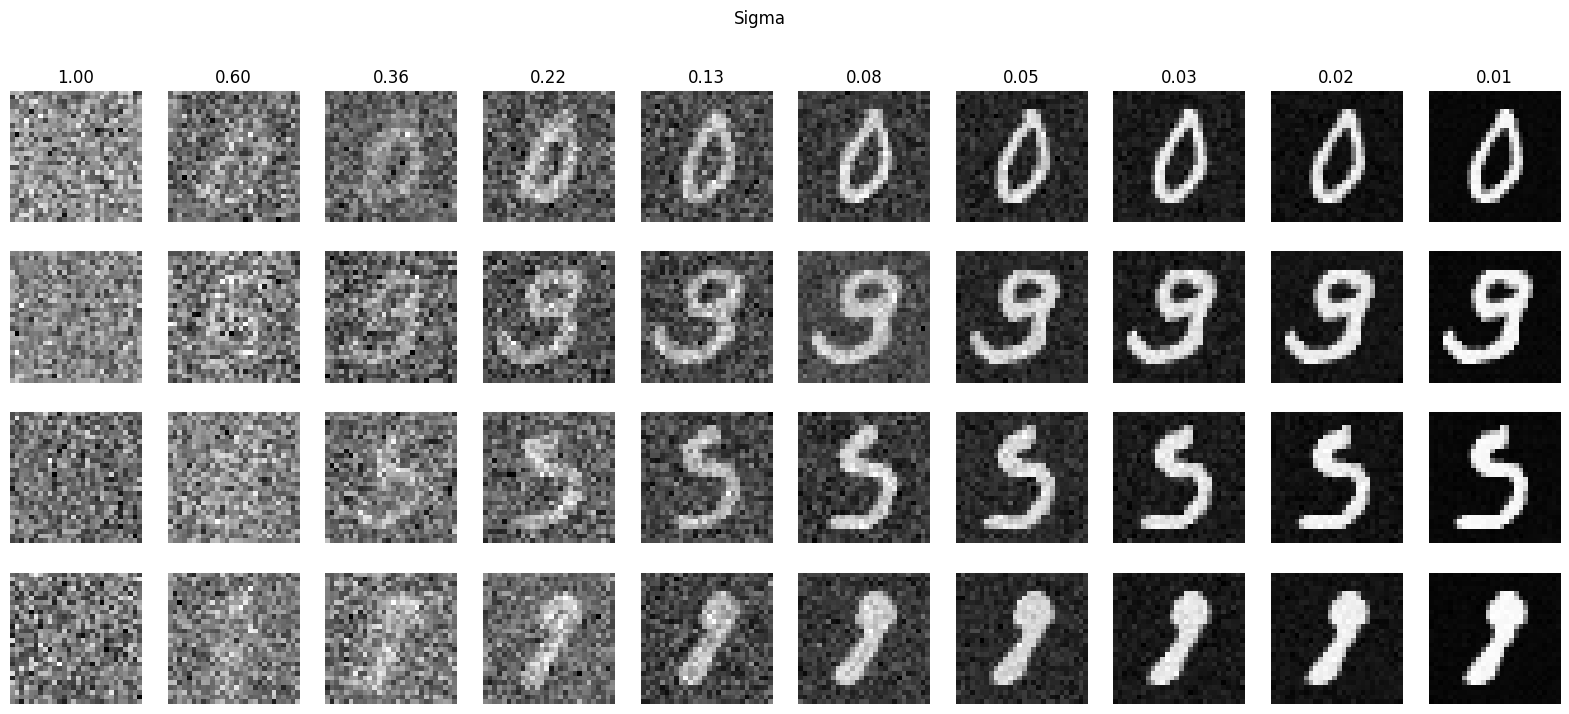

In [110]:
# use if loading a model from a checkpoint
model = RefineNet(in_channels=1)

chkpt_pth = torch.load("checkpoints/baseline/checkpoint_epoch30_baseline.pth")
model.load_state_dict(chkpt_pth['model_state_dict'])
model = model.to(device)

/tmp/ipykernel_229585/2286559010.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpt_pth = torch.load("checkpoints/baseline/checkpoint_epoch30_baseline.pth")


In [126]:
from tqdm import trange

def sample_refinenet(model, shape, noise_scales, device, n_steps, eps, visualize_dynamics_file):
    """Generates images using the model that was trained with score matching.
    noise_scales: Sigmas for annealed LD.
    n_steps: Number of steps for each sigma.
    eps: Step size in LD.
    visualize_dynamics_file: Saves the dynamics (the denoising process of the Langevin dynamics) in a file.
    """
    model.eval()
    with torch.no_grad():
        fig, ax = plt.subplots(shape[0], len(noise_scales), figsize=(len(noise_scales)*2, shape[0]*2))
        fig.suptitle('Sigma')
        
        ### YOUR CODE HERE ###
        x = torch.rand(shape).to(device)

        for i, sigma_i in enumerate(noise_scales):
            noise_idx = torch.ones(shape[0], dtype=torch.int, device=device) * i
            lr = eps * ((sigma_i ** 2) / (noise_scales[-1] ** 2))
            for step in trange(n_steps):
                # sampling noise
                noise = torch.randn(shape, device=device)
                score = model(x, noise_idx)
                # moving towards the real score + noise
                x = x + 0.5 * lr * score + torch.sqrt(lr) * noise
            img = x.clamp(0, 1).squeeze(1).to('cpu')
            [ax[img_idx,i].imshow(img[img_idx], cmap='gray') for img_idx in range(shape[0])]
        
        fig.savefig('images/mnist_generated.png')

100%|██████████| 100/100 [00:02<00:00, 40.81it/s]


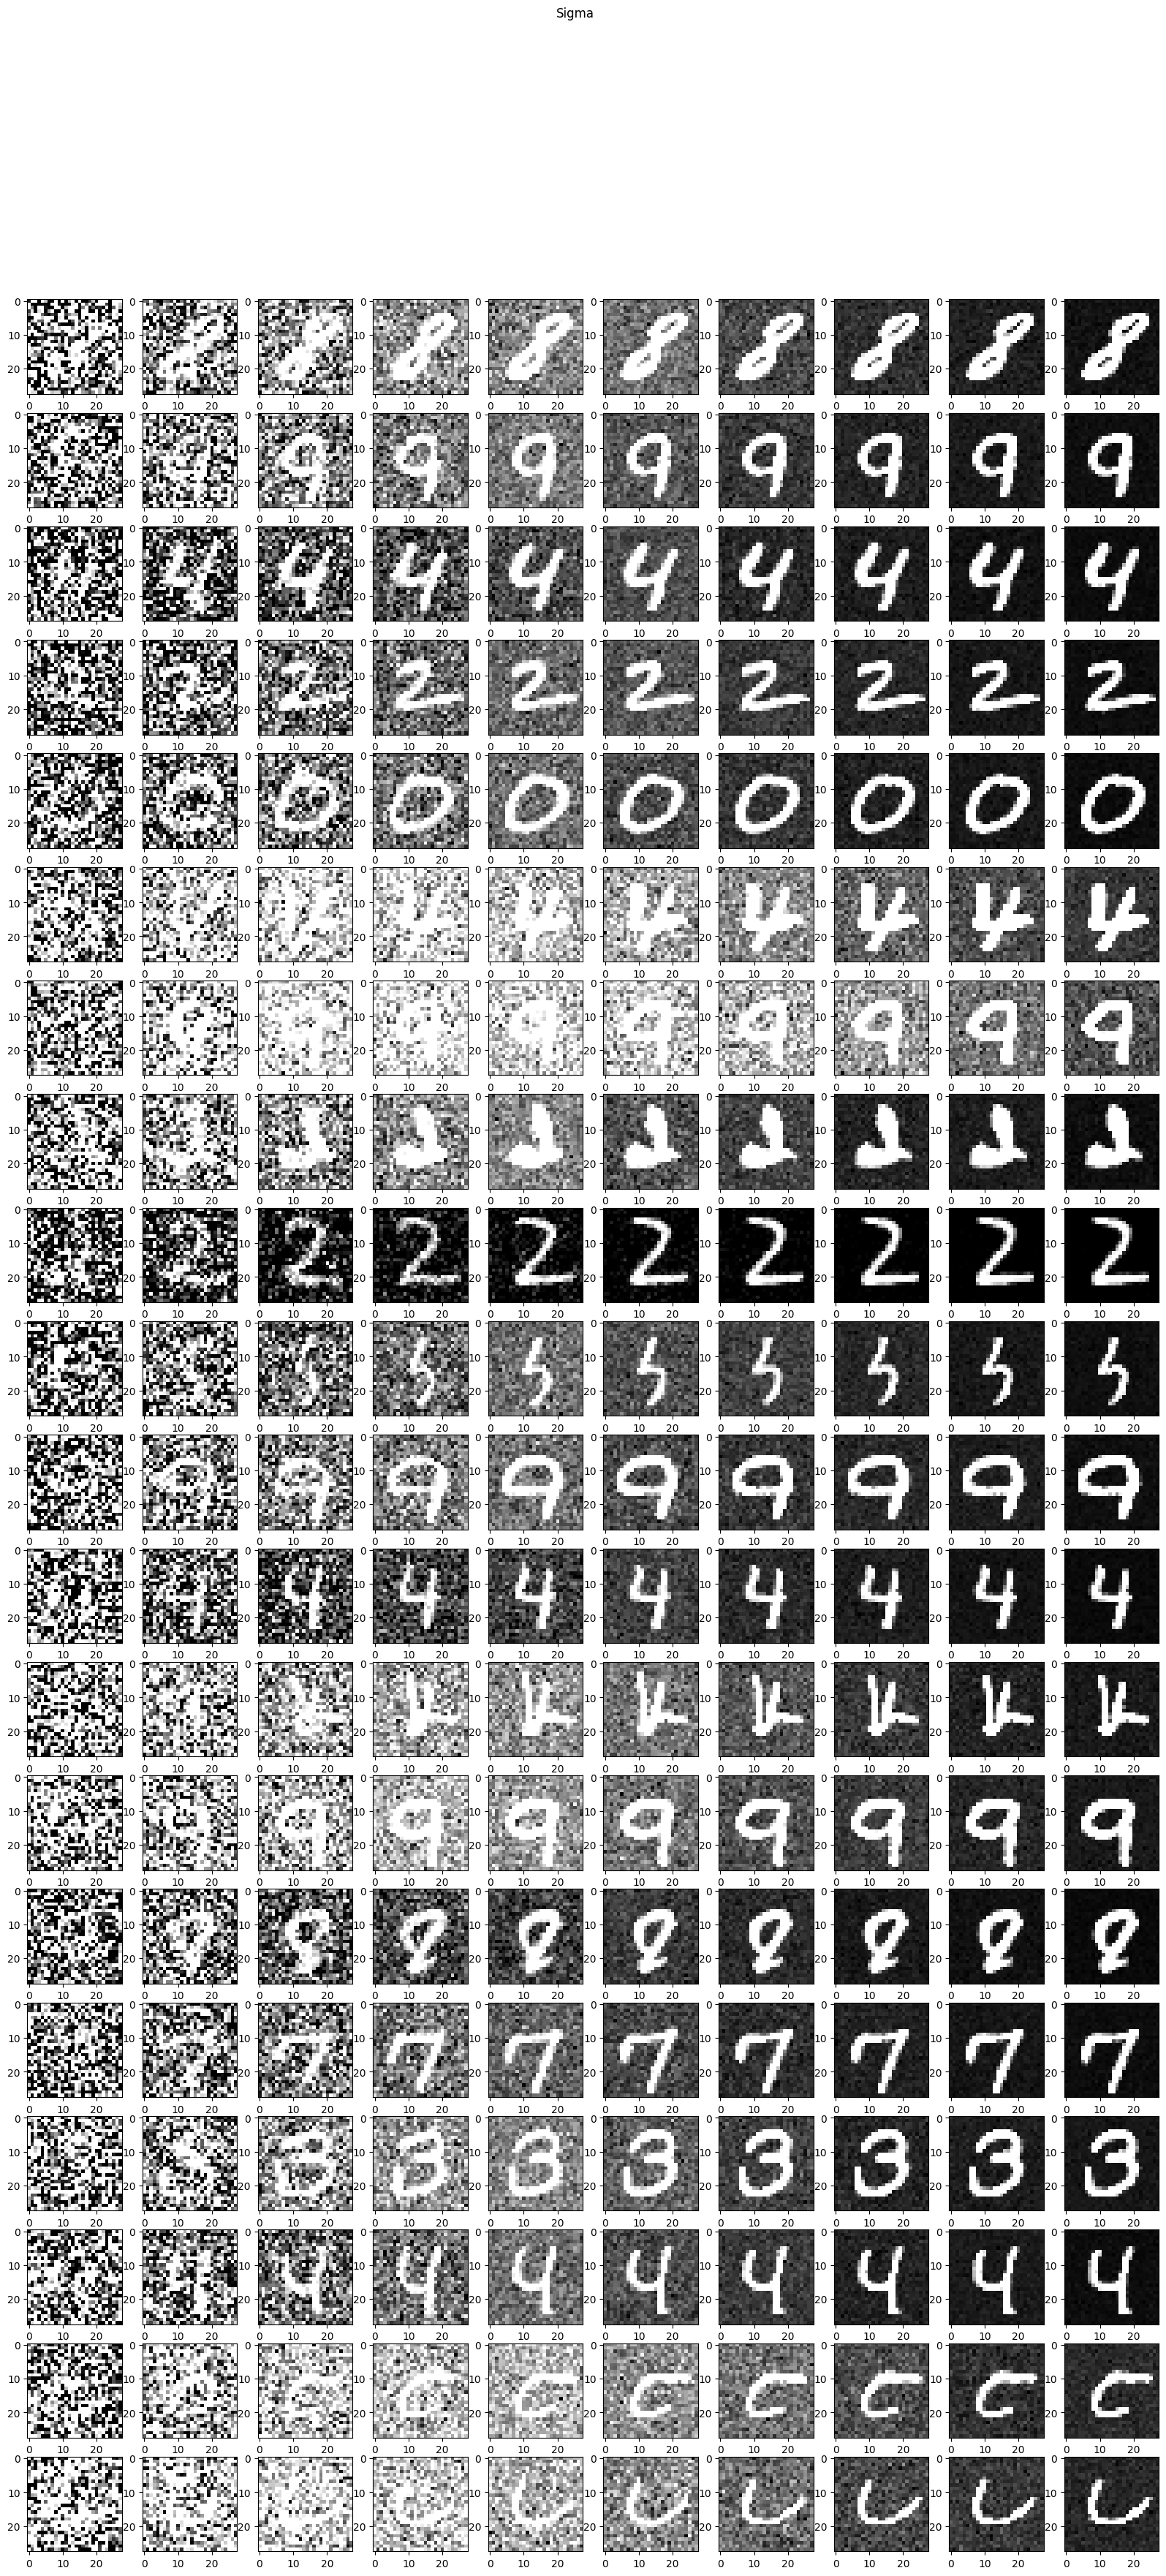

In [127]:
# Sample from the RefineNet model
sample_refinenet(model, shape=(20, 1, 28, 28), noise_scales = NOISE_SCALES, device=device, n_steps=NUM_LANGEVIN_STEPS, eps=LANGEVIN_STEP_SIZE, visualize_dynamics_file='images/generated.png')